<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Standford-dogs-CNN-project-/blob/main/7_transfer_learning_feature_extraction_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 7 — Transfer Learning: Feature Extraction**

Rather than training from scratch, transfer learning lets us reuse a model
already trained on ImageNet (1.2M images, 1000 classes). It already knows
how to detect edges, textures, shapes we just teach the last part:
mapping those features to 120 dog breeds.

## *What this notebook does*
Compare three lightweight pretrained models using feature extraction only
(base frozen, only the classification head trains) to find the best base
for fine tuning in notebook 8.

## *When transfer learning wouldn't make sense*
- Medical imaging (X-rays, MRIs) — ImageNet features don't transfer well
- Satellite imagery — completely different visual domain  
- Industrial defect detection — textures look nothing like natural images

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import kagglehub
import os

path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")

dataset_path = os.path.join(path, "images", "Images")


train_data = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(128, 128),
    validation_split=0.2,
    subset='training',
    seed=42
)

val_data = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(128, 128),
    validation_split=0.2,
    subset='validation',
    seed=42
)

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)

Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.
Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


## Model builder
All three models use the same head architecture so the comparison is fair.
Only the base changes everything else (dropout, dense layer, optimizer,
learning rate, epochs) stays identical.

In [ ]:
def build_model(base_model,preprocess_fn):
  base_model.trainable = False

  inputs = keras.Input(shape=(128,128,3))
  x=preprocess_fn(inputs)
  x=base_model(x)
  x=layers.GlobalAveragePooling2D()(x)
  x=layers.Dropout(0.3)(x)
  outputs=layers.Dense(120,activation='softmax')(x)

  model=keras.Model(inputs,outputs)
  model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
  )
  return model



## **Experiment A — MobileNetV2**
Smallest and fastest of the three. Designed for mobile/edge devices.
Good baseline for transfer learning but not the most powerful.

In [ ]:
mobilenet =keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)
mobilenet_model=build_model(mobilenet,keras.applications.mobilenet_v2.preprocess_input)

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,411,704 (9.20 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)
mobilenet_val_acc = max(history_mobilenet.history['val_accuracy'])
print(f"\nMobileNetV2 → Best val accuracy: {mobilenet_val_acc:.4f}")



Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 74s 111ms/step - accuracy: 0.5939 - loss: 1.5353 - val_accuracy: 0.7420 - val_loss: 0.8992
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.7905 - loss: 0.6627 - val_accuracy: 0.7522 - val_loss: 0.8561
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - accuracy: 0.8497 - loss: 0.4738 - val_accuracy: 0.7500 - val_loss: 0.8669
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.8811 - loss: 0.3647 - val_accuracy: 0.7505 - val_loss: 0.8770
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.9066 - loss: 0.2923 - val_accuracy: 0.7485 - val_loss: 0.9015
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - accuracy: 0.9220 - loss: 0.2475 - val_accuracy: 0.7451 - val_loss: 0.9318
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.9339 - loss: 0.2100 - val_accuracy: 0.7544 - val_loss: 0.9359
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.9417 - loss: 0.1832 -

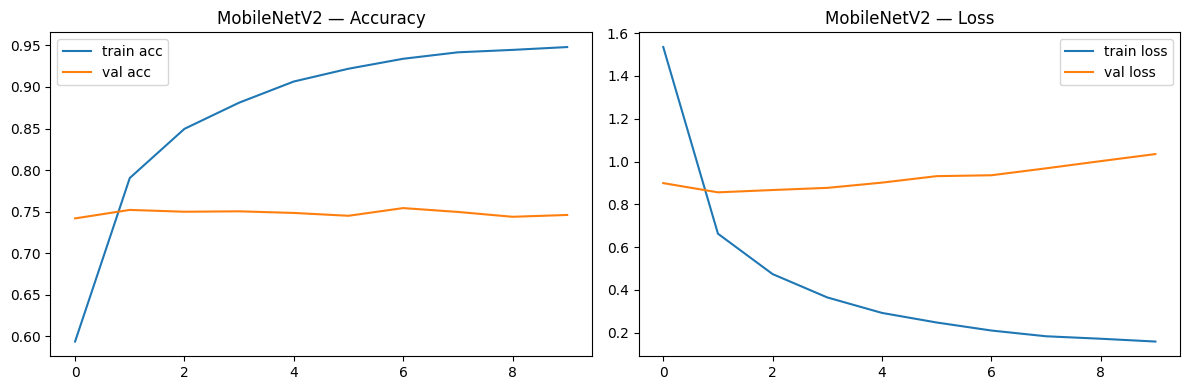

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'], label='train acc')
plt.plot(history_mobilenet.history['val_accuracy'], label='val acc')
plt.title('MobileNetV2 — Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['loss'], label='train loss')
plt.plot(history_mobilenet.history['val_loss'], label='val loss')
plt.title('MobileNetV2 — Loss')
plt.legend()

plt.tight_layout()
plt.show()

## **Experiment B — EfficientNetB0**
Slightly heavier than MobileNetV2 but significantly better accuracy.
Uses compound scaling balances depth, width, and resolution together
rather than scaling one dimension at a time.

In [ ]:
efficientnet= keras.applications.EfficientNetB0(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)
efficientnet_model = build_model(efficientnet,keras.applications.efficientnet.preprocess_input)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203,291 (16.03 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history_efficientnet = efficientnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

efficientnet_val_acc = max(history_efficientnet.history['val_accuracy'])
print(f"\nEfficientNetB0 → Best val accuracy: {efficientnet_val_acc:.4f}")

Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 84s 117ms/step - accuracy: 0.5434 - loss: 1.9626 - val_accuracy: 0.6856 - val_loss: 1.1441
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.7129 - loss: 1.0180 - val_accuracy: 0.6983 - val_loss: 1.0451
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.7583 - loss: 0.8346 - val_accuracy: 0.7007 - val_loss: 1.0290
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.7864 - loss: 0.7190 - val_accuracy: 0.6985 - val_loss: 1.0296
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.8125 - loss: 0.6352 - val_accuracy: 0.7021 - val_loss: 1.0373
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.8266 - loss: 0.5749 - val_accuracy: 0.7000 - val_loss: 1.0487
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - accuracy: 0.8395 - loss: 0.5339 - val_accuracy: 0.6995 - val_loss: 1.0605
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.8522 - loss: 0.4870 -

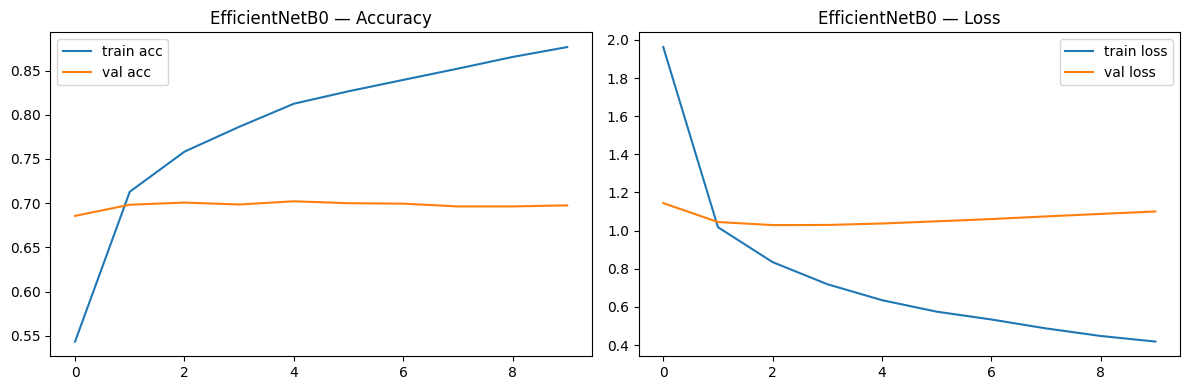

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_efficientnet.history['accuracy'], label='train acc')
plt.plot(history_efficientnet.history['val_accuracy'], label='val acc')
plt.title('EfficientNetB0 — Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_efficientnet.history['loss'], label='train loss')
plt.plot(history_efficientnet.history['val_loss'], label='val loss')
plt.title('EfficientNetB0 — Loss')
plt.legend()

plt.tight_layout()
plt.show()

## **Experiment C — NASNetMobile**
Architecture found by neural architecture search optimized specifically
to be lightweight while maintaining strong accuracy. Good middle ground
between MobileNetV2 and EfficientNetB0.

In [ ]:
nasnet= keras.applications.NASNetMobile(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)
nasnet_model=build_model(nasnet,keras.applications.nasnet.preprocess_input)

nasnet_model.summary()

19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ nasnet_mobile (Functional)      │ (None, 4, 4, 1056)     │     4,269,716 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1056)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1056)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │       126,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,396,556 (16.77 MB)

 Trainable params: 126,840 (495.47 KB)

 Non-trainable params: 4,269,716 (16.29 MB)

In [ ]:
history_nasnet = nasnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

nasnet_val_acc = max(history_nasnet.history['val_accuracy'])
print(f"\nNASNetMobile → Best val accuracy: {nasnet_val_acc:.4f}")

Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 145s 194ms/step - accuracy: 0.4646 - loss: 2.4271 - val_accuracy: 0.5600 - val_loss: 1.8231
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.5712 - loss: 1.7306 - val_accuracy: 0.5629 - val_loss: 1.8502
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.6092 - loss: 1.4892 - val_accuracy: 0.5520 - val_loss: 1.9272
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.6358 - loss: 1.3424 - val_accuracy: 0.5663 - val_loss: 1.9303
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.6628 - loss: 1.2193 - val_accuracy: 0.5578 - val_loss: 1.9834
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.6705 - loss: 1.1519 - val_accuracy: 0.5617 - val_loss: 2.0368
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 39s 75ms/step - accuracy: 0.6872 - loss: 1.0803 - val_accuracy: 0.5661 - val_loss: 2.0869
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.6987 - loss: 1.0405 

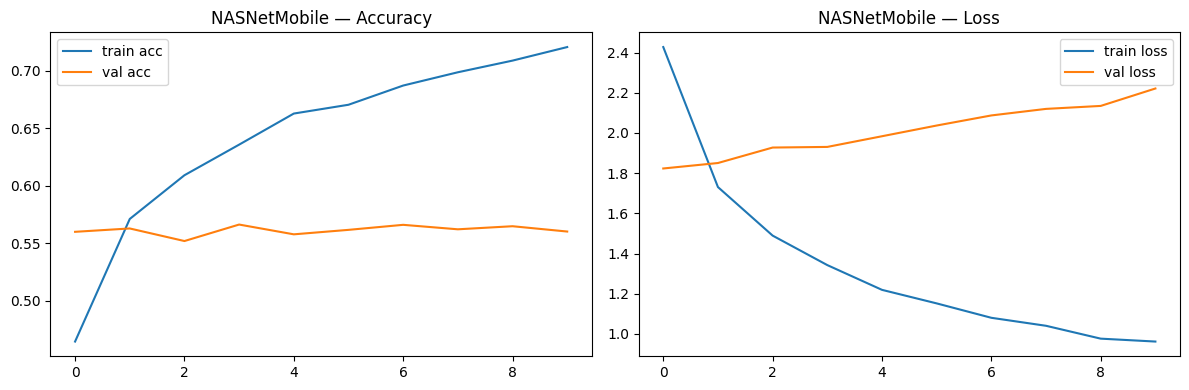

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_nasnet.history['accuracy'], label='train acc')
plt.plot(history_nasnet.history['val_accuracy'], label='val acc')
plt.title('NASNetMobile — Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_nasnet.history['loss'], label='train loss')
plt.plot(history_nasnet.history['val_loss'], label='val loss')
plt.title('NASNetMobile — Loss')
plt.legend()

plt.tight_layout()
plt.show()

## **Experiment D — ResNet50**
25.6M parameters,significantly heavier than the three mobile models.
Uses residual connections (skip connections) to train much deeper networks
without vanishing gradients. Likely the strongest performer here but at
higher compute cost.

In [ ]:
resnet = keras.applications.ResNet50(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

resnet_model = build_model(
    resnet,
    keras.applications.resnet.preprocess_input
)

resnet_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 128, 128,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 120)       │    245,880 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,833,592 (90.92 MB)

 Trainable params: 245,880 (960.47 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

resnet_val_acc = max(history_resnet.history['val_accuracy'])
print(f"\nResNet50 → Best val accuracy: {resnet_val_acc:.4f}")

Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 90s 154ms/step - accuracy: 0.3820 - loss: 3.2897 - val_accuracy: 0.5379 - val_loss: 2.2797
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.5666 - loss: 2.0192 - val_accuracy: 0.5432 - val_loss: 2.3707
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.6311 - loss: 1.6014 - val_accuracy: 0.5527 - val_loss: 2.4173
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.6731 - loss: 1.3471 - val_accuracy: 0.5539 - val_loss: 2.6034
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7030 - loss: 1.2122 - val_accuracy: 0.5471 - val_loss: 2.7017
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - accuracy: 0.7274 - loss: 1.0850 - val_accuracy: 0.5641 - val_loss: 2.7170
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.7491 - loss: 0.9776 - val_accuracy: 0.5656 - val_loss: 2.8402
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - accuracy: 0.7570 - loss: 0.9444 -

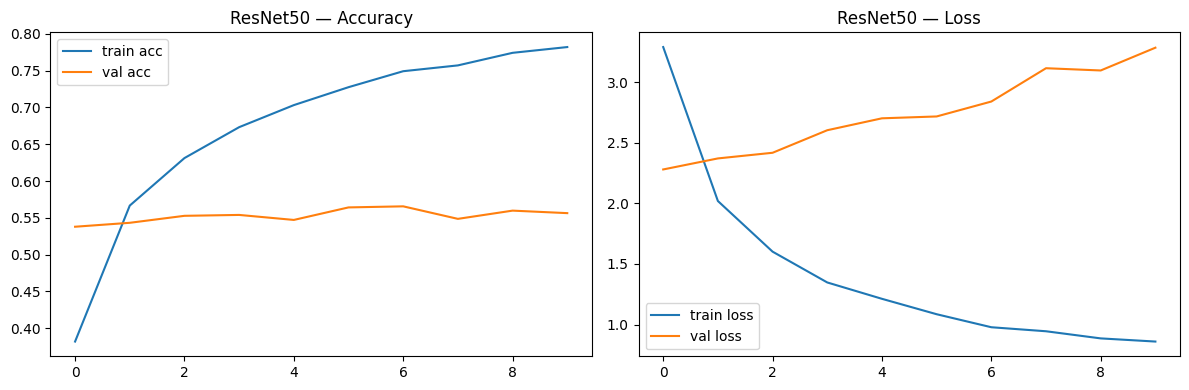

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_resnet.history['accuracy'], label='train acc')
plt.plot(history_resnet.history['val_accuracy'], label='val acc')
plt.title('ResNet50 — Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_resnet.history['loss'], label='train loss')
plt.plot(history_resnet.history['val_loss'], label='val loss')
plt.title('ResNet50 — Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Conclusion

| Model          | Val Accuracy | Params  | Notes                          |
|----------------|--------------|---------|--------------------------------|
| MobileNetV2    | 75.44%       | 3.4M    | Winner — fastest AND best  |
| EfficientNetB0 | 70.21%       | 5.3M    | Strong but didn't beat Mobile  |
| NASNetMobile   | 56.63%       | 5.3M    | Underperformed expectations    |
| ResNet50       | 56.56%       | 25.6M   | Heavy compute, weakest result  |

**Winner: MobileNetV2 (75.44%)**

The result goes against the assumption that bigger = better for this perticular dataset.
MobileNetV2's depthwise separable convolutions appear to extract
features more efficiently for this specific task than ResNet50's
deeper residual architecture despite having 7x fewer parameters.

ResNet50 being the weakest is the most surprising result.
Likely reasons:
- Feature extraction only (frozen base) — ResNet may need fine tuning
  to unlock its full potential, unlike MobileNetV2 which transfers well frozen
- 128×128 input may be too small for ResNet50 to leverage its depth effectively

-------------------------------

## **Decision : MobileNetV2 carries forward to notebook 8 for fine tuning.**

### Why did MobileNetV2 perform best?

*Several factors may explain MobileNetV2's superior performance on this dataset:*

*- **Efficient feature extraction:** MobileNetV2 uses depthwise separable convolutions, allowing it to learn useful visual features with significantly fewer parameters than ResNet50. This can improve generalization when training data is limited.*

*- **Better transferability in frozen mode:** Since all pretrained backbones were used as fixed feature extractors, MobileNetV2 may have produced features that transferred more effectively to the 120-class dataset without requiring fine-tuning.*

*- **Input resolution compatibility:** The models were trained on 128×128 images. MobileNetV2 is often more robust at lower resolutions, whereas deeper architectures such as ResNet50 may benefit more from larger input sizes.*

*- **Reduced overfitting risk:** With substantially fewer parameters than ResNet50, MobileNetV2 may have been less prone to learning dataset-specific noise and therefore generalized better on the validation set.*

*While these explanations are consistent with the observed results, further experiments involving fine tuning and higher input resolutions would be required to confirm them.*